In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import scanpy as sc
import squidpy as sq

C:\Users\enric\tangram\.venv\Lib\site-packages\dask\dataframe\__init__.py:31: FutureWarning: The legacy Dask DataFrame implementation is deprecated and will be removed in a future version. Set the configuration option `dataframe.query-planning` to `True` or None to enable the new Dask Dataframe implementation and silence this warning.
  warnings.warn(
C:\Users\enric\tangram\.venv\Lib\site-packages\anndata\utils.py:434: FutureWarning: Importing read_text from `anndata` is deprecated. Import anndata.io.read_text instead.
  warnings.warn(msg, FutureWarning)


In [2]:
 import mytangram as tg

In [3]:
!cd

C:\Users\enric\tangram


Before reading Drive files it is necessary to prompt Windows to load the full file in the local machine (stream mode). One can do this manually by opening the local Drive disk on the file explorer or automatically exploiting a python script to load metadata:

In [10]:
### Does not work --- skip

import os

# Touch the file to prompt Windows to load it (may trigger Drive to stream it)
try:
    os.stat(r"H:/Il mio Drive/dati_per_enrico.lnk/counts100k_norm_wo_raw.h5ad")
    print("File metadata accessed.")
except FileNotFoundError:
    print("File not accessible yet.")

File not accessible yet.


Retrieve true file path in drive through link:

In [4]:
!uv pip install winshell

Resolved 1 package in 188ms
Installed 1 package in 25ms
 + winshell==0.6


In [5]:
import winshell
import os

shortcut_path = r"H:/Il mio Drive/dati_per_enrico.lnk"
real_path = winshell.shortcut(shortcut_path).path

print(f"Real path: {real_path}")

# Now test it
if os.path.exists(real_path):
    print("Resolved path is accessible")
else:
    print("Resolved path is not available")


Real path: H:\.shortcut-targets-by-id\1UGLL2UOn-9s1OY1r9mGMc1RFF7REij9e\dati_per_enrico
Resolved path is accessible


In [6]:
%cd H:/Il mio Drive/

H:\Il mio Drive


In [ ]:
!dir /a

# Training genes set
The purpose of this notebook is to investgate how different training genes sets affect the mapping results, exploring the relevancy of genes' expression levels in both scRNA data and spatial data.

# SC Data

## Data loading

The dataset of choice for scRNA-seq data is loaded directly from squidpy. The scanpy documentation offers the follwong descirption:

"
Pre-processed scRNA-seq mouse cortex.

The shape of this anndata.AnnData object (21697, 36826).
"

In [7]:
#adata_sc = sq.datasets.sc_mouse_cortex()
adata_sc= sc.read_h5ad('H:/Il mio Drive/dati_per_enrico.lnk/counts100k_norm_wo_raw.h5ad')
adata_sc

AnnData object with n_obs × n_vars = 100000 × 31053
    obs: 'nUMI', 'nGene', 'dataset', 'QC', 'cluster', 'Allen.cluster_id', 'Allen.cluster_label', 'Allen.cluster_color', 'Allen.class_label', 'Allen.subclass_label', 'comb.QC'
    var: 'gene_ids', 'feature_types'

In [8]:
adata_sc.obs.head()

,nUMI,nGene,dataset,QC,cluster,Allen.cluster_id,Allen.cluster_label,Allen.cluster_color,Allen.class_label,Allen.subclass_label,comb.QC
pBICCNsMMrMOpRPiF006d190314_CTCATCGTCCGCTAGG,14213,4810,FEMALE,PassQC,Ex3_5,66.0,L6 CT Cpa6,#338C5E,Glutamatergic,L6 CT,PassQC
pBICCNsMMrMOpRMiF004d190318_TCCGAAACAAATCAAG,2333,1514,FEMALE,PassQC,Fibro1_5,98.0,VLMC_3,#476655,Non-Neuronal,VLMC,PassQC
pBICCNsMMrMOpRPiM008d190320_GACACGCGTTCAGCGC,2253,1319,MALE,PassQC,Oligo_21,90.0,Oligo Opalin_4,#474662,Non-Neuronal,Oligo,PassQC
pBICCNsMMrMOpRAiM008d190320_TTCGGTCGTGTATTCG,1440,1078,MALE,PassQC,Micro_0,113.0,Macrophage_2,#476655,Non-Neuronal,Macrophage,PassQC
pBICCNsMMrMOpRMiF007d190314_TATTCCAGTCCAACGC,10699,3897,FEMALE,PassQC,Ex5_2,64.0,L5/6 NP_3,#47867A,Glutamatergic,L5/6 NP,PassQC


In [9]:
adata_sc.var.head()

,gene_ids,feature_types
Xkr4,0,Gene Expression
Gm1992,1,Gene Expression
Gm37381,2,Gene Expression
Rp1,3,Gene Expression
Sox17,4,Gene Expression


In [10]:
adata_sc.X

<Compressed Sparse Column sparse matrix of dtype 'float64'
	with 369013597 stored elements and shape (100000, 31053)>

### HVGs

Here we identfy the subset of highly variable genes with Scanpy's built-in preprocessing function:

<dt><strong>flavor</strong> <span class="classifier"><span class="sphinx_autodoc_typehints-type"><a class="reference external" href="https://docs.python.org/3/library/typing.html#typing.Literal" title="(in Python v3.13)"><code class="xref py py-data docutils literal notranslate"><span class="pre">Literal</span></code></a>[<code class="docutils literal notranslate"><span class="pre">'seurat'</span></code>, <code class="docutils literal notranslate"><span class="pre">'cell_ranger'</span></code>, <code class="docutils literal notranslate"><span class="pre">'seurat_v3'</span></code>, <code class="docutils literal notranslate"><span class="pre">'seurat_v3_paper'</span></code>]</span> (default: <code class="docutils literal notranslate"><span class="pre">'seurat'</span></code>)</span></dt></dt><dd><p>Choose the flavor for identifying highly variable genes. For the dispersion
based methods in their default workflows, Seurat passes the cutoffs whereas
Cell Ranger passes <code class="docutils literal notranslate"><span class="pre">n_top_genes</span></code>.</p>
</dd>

<p>Depending on <code class="docutils literal notranslate"><span class="pre">flavor</span></code>, this reproduces the R-implementations of Seurat
<span id="id2">[<a class="reference internal" href="../references.html#id54" title="Rahul Satija, Jeffrey A Farrell, David Gennert, Alexander F Schier, and Aviv Regev. Spatial reconstruction of single-cell gene expression data. Nature Biotechnology, 33(5):495–502, apr 2015. URL: https://doi.org/10.1038/nbt.3192, doi:10.1038/nbt.3192.">Satija <em>et al.</em>, 2015</a>]</span>, Cell Ranger <span id="id3">[<a class="reference internal" href="../references.html#id76" title="Grace X. Y. Zheng, Jessica M. Terry, Phillip Belgrader, Paul Ryvkin, Zachary W. Bent, Ryan Wilson, Solongo B. Ziraldo, Tobias D. Wheeler, Geoff P. McDermott, Junjie Zhu, Mark T. Gregory, Joe Shuga, Luz Montesclaros, Jason G. Underwood, Donald A. Masquelier, Stefanie Y. Nishimura, Michael Schnall-Levin, Paul W. Wyatt, Christopher M. Hindson, Rajiv Bharadwaj, Alexander Wong, Kevin D. Ness, Lan W. Beppu, H. Joachim Deeg, Christopher McFarland, Keith R. Loeb, William J. Valente, Nolan G. Ericson, Emily A. Stevens, Jerald P. Radich, Tarjei S. Mikkelsen, Benjamin J. Hindson, and Jason H. Bielas. Massively parallel digital transcriptional profiling of single cells. Nature Communications, jan 2017. URL: https://doi.org/10.1038/ncomms14049, doi:10.1038/ncomms14049.">Zheng <em>et al.</em>, 2017</a>]</span>, and Seurat v3 <span id="id4">[<a class="reference internal" href="../references.html#id61" title="Tim Stuart, Andrew Butler, Paul Hoffman, Christoph Hafemeister, Efthymia Papalexi, William M. Mauck, Yuhan Hao, Marlon Stoeckius, Peter Smibert, and Rahul Satija. Comprehensive integration of single-cell data. Cell, 177(7):1888–1902.e21, jun 2019. URL: https://doi.org/10.1016/j.cell.2019.05.031, doi:10.1016/j.cell.2019.05.031.">Stuart <em>et al.</em>, 2019</a>]</span>.</p>
<p><code class="docutils literal notranslate"><span class="pre">'seurat_v3'</span></code>/<code class="docutils literal notranslate"><span class="pre">'seurat_v3_paper'</span></code> requires <code class="docutils literal notranslate"><span class="pre">scikit-misc</span></code> package. If you plan to use this flavor, consider
installing <code class="docutils literal notranslate"><span class="pre">scanpy</span></code> with this optional dependency: <code class="docutils literal notranslate"><span class="pre">scanpy[skmisc]</span></code>.</p>
<p>For the dispersion-based methods (<code class="docutils literal notranslate"><span class="pre">flavor='seurat'</span></code> <span id="id5">Satija <em>et al.</em> [<a class="reference internal" href="../references.html#id54" title="Rahul Satija, Jeffrey A Farrell, David Gennert, Alexander F Schier, and Aviv Regev. Spatial reconstruction of single-cell gene expression data. Nature Biotechnology, 33(5):495–502, apr 2015. URL: https://doi.org/10.1038/nbt.3192, doi:10.1038/nbt.3192.">2015</a>]</span> and
<code class="docutils literal notranslate"><span class="pre">flavor='cell_ranger'</span></code> <span id="id6">Zheng <em>et al.</em> [<a class="reference internal" href="../references.html#id76" title="Grace X. Y. Zheng, Jessica M. Terry, Phillip Belgrader, Paul Ryvkin, Zachary W. Bent, Ryan Wilson, Solongo B. Ziraldo, Tobias D. Wheeler, Geoff P. McDermott, Junjie Zhu, Mark T. Gregory, Joe Shuga, Luz Montesclaros, Jason G. Underwood, Donald A. Masquelier, Stefanie Y. Nishimura, Michael Schnall-Levin, Paul W. Wyatt, Christopher M. Hindson, Rajiv Bharadwaj, Alexander Wong, Kevin D. Ness, Lan W. Beppu, H. Joachim Deeg, Christopher McFarland, Keith R. Loeb, William J. Valente, Nolan G. Ericson, Emily A. Stevens, Jerald P. Radich, Tarjei S. Mikkelsen, Benjamin J. Hindson, and Jason H. Bielas. Massively parallel digital transcriptional profiling of single cells. Nature Communications, jan 2017. URL: https://doi.org/10.1038/ncomms14049, doi:10.1038/ncomms14049.">2017</a>]</span>), the normalized dispersion is obtained
by scaling with the mean and standard deviation of the dispersions for genes
falling into a given bin for mean expression of genes. This means that for each
bin of mean expression, highly variable genes are selected.</p>
<p>For <code class="docutils literal notranslate"><span class="pre">flavor='seurat_v3'</span></code>/<code class="docutils literal notranslate"><span class="pre">'seurat_v3_paper'</span></code> <span id="id7">[<a class="reference internal" href="../references.html#id61" title="Tim Stuart, Andrew Butler, Paul Hoffman, Christoph Hafemeister, Efthymia Papalexi, William M. Mauck, Yuhan Hao, Marlon Stoeckius, Peter Smibert, and Rahul Satija. Comprehensive integration of single-cell data. Cell, 177(7):1888–1902.e21, jun 2019. URL: https://doi.org/10.1016/j.cell.2019.05.031, doi:10.1016/j.cell.2019.05.031.">Stuart <em>et al.</em>, 2019</a>]</span>, a normalized variance for each gene
is computed. First, the data are standardized (i.e., z-score normalization
per feature) with a regularized standard deviation. Next, the normalized variance
is computed as the variance of each gene after the transformation. Genes are ranked
by the normalized variance.
Only if <code class="docutils literal notranslate"><span class="pre">batch_key</span></code> is not <code class="docutils literal notranslate"><span class="pre">None</span></code>, the two flavors differ: For <code class="docutils literal notranslate"><span class="pre">flavor='seurat_v3'</span></code>, genes are first sorted by the median (across batches) rank, with ties broken by the number of batches a gene is a HVG.
For <code class="docutils literal notranslate"><span class="pre">flavor='seurat_v3_paper'</span></code>, genes are first sorted by the number of batches a gene is a HVG, with ties broken by the median (across batches) rank.</p>
<p>The following may help when comparing to Seurat’s naming:
If <code class="docutils literal notranslate"><span class="pre">batch_key=None</span></code> and <code class="docutils literal notranslate"><span class="pre">flavor='seurat'</span></code>, this mimics Seurat’s <code class="docutils literal notranslate"><span class="pre">FindVariableFeatures(…,</span> <span class="pre">method='mean.var.plot')</span></code>.
If <code class="docutils literal notranslate"><span class="pre">batch_key=None</span></code> and <code class="docutils literal notranslate"><span class="pre">flavor='seurat_v3'</span></code>/<code class="docutils literal notranslate"><span class="pre">flavor='seurat_v3_paper'</span></code>, this mimics Seurat’s <code class="docutils literal notranslate"><span class="pre">FindVariableFeatures(...,</span> <span class="pre">method='vst')</span></code>.
If <code class="docutils literal notranslate"><span class="pre">batch_key</span></code> is not <code class="docutils literal notranslate"><span class="pre">None</span></code> and <code class="docutils literal notranslate"><span class="pre">flavor='seurat_v3_paper'</span></code>, this mimics Seurat’s <code class="docutils literal notranslate"><span class="pre">SelectIntegrationFeatures</span></code>.</p>
<p>See also <code class="docutils literal notranslate"><span class="pre">scanpy.experimental.pp._highly_variable_genes</span></code> for additional flavors
(e.g. Pearson residuals).</p>

In [11]:
# Solve dependency issue for sc.pp.highly_variable_genes()
!uv pip install scikit-misc

Resolved 2 packages in 273ms
Installed 2 packages in 1.22s
 + numpy==2.2.6
 + scikit-misc==0.5.1


In [12]:
sc.pp.highly_variable_genes(adata_sc, n_top_genes=2000, flavor='seurat_v3')

In [13]:
adata_sc.uns['hvg']

{'flavor': 'seurat_v3'}

The highly variables genes set is available as a mask on the variables of the AnnData object:

In [14]:
adata_sc.var['highly_variable']

Xkr4              False
Gm1992            False
Gm37381           False
Rp1               False
Sox17              True
                  ...  
AC168977.1        False
AC149090.1        False
CAAA01118383.1    False
Vmn2r122          False
CAAA01147332.1    False
Name: highly_variable, Length: 31053, dtype: bool

with a total of hvg equal to:

In [15]:
sum(adata_sc.var['highly_variable'])

2000

## Sparsity

Now, we count the number of all-zero genes:

In [32]:
all_zero_count = sum(np.array(adata_sc.X.sum(axis=0)).flatten() == 0)

In [33]:
print('All zeros genes:', all_zero_count)

All zeros genes: 3581


Then we can check the sparsity level of the counts matrix by accesing the 

In [118]:
sparsity = 1 - adata_sc.X.nnz / (adata_sc.n_obs * adata_sc.n_vars)  
# equivalent values
# adata_sc.X.size
# adata_sc.X.shape[0]
# adata_sc.X.shape[1]

In [124]:
print('Sparsity level of sc data:', '{} %'.format(round(sparsity, 3)*100))

Sparsity level of sc data: 86.6 %


# Spatial Data

## Data loading
The spatial dataset comes from squidpy as well, It is a MERFISH dataset.

"Pre-processed MERFISH dataset from Moffitt et al.

The shape of this anndata.AnnData object (73655, 161).
"

In [16]:
#adata_st = sq.datasets.merfish()
adata_st_153 = sc.read_h5ad('H:/Il mio Drive/dati_per_enrico.lnk/slice153_norm_wo_raw.h5ad')
adata_st_153

AnnData object with n_obs × n_vars = 7469 × 254
    obs: 'sample_id', 'slice_id', 'class_label', 'subclass', 'label', 'instance_id', 'centroid_x', 'centroid_y', 'region'
    var: 'is_sequential', 'is_combinatorial'
    uns: 'spatialdata_attrs'

In [38]:
adata_st_200 = sc.read_h5ad('H:/Il mio Drive/dati_per_enrico.lnk/slice200_norm_wo_raw.h5ad')
adata_st_200

AnnData object with n_obs × n_vars = 2155 × 254
    obs: 'sample_id', 'slice_id', 'class_label', 'subclass', 'label', 'instance_id', 'centroid_x', 'centroid_y', 'region'
    var: 'is_sequential', 'is_combinatorial'
    uns: 'spatialdata_attrs'

In [39]:
adata_st_102 = sc.read_h5ad('H:/Il mio Drive/dati_per_enrico.lnk/slice102_norm_wo_raw.h5ad')
adata_st_102

AnnData object with n_obs × n_vars = 6731 × 254
    obs: 'sample_id', 'slice_id', 'class_label', 'subclass', 'label', 'instance_id', 'centroid_x', 'centroid_y', 'region'
    var: 'is_sequential', 'is_combinatorial'
    uns: 'spatialdata_attrs'

In [40]:
adata_st_40 = sc.read_h5ad('H:/Il mio Drive/dati_per_enrico.lnk/slice40_norm_wo_raw.h5ad')
adata_st_40

AnnData object with n_obs × n_vars = 4070 × 254
    obs: 'sample_id', 'slice_id', 'class_label', 'subclass', 'label', 'instance_id', 'centroid_x', 'centroid_y', 'region'
    var: 'is_sequential', 'is_combinatorial'
    uns: 'spatialdata_attrs'

In [41]:
adata_st_153.obs.head()

,sample_id,slice_id,class_label,subclass,label,instance_id,centroid_x,centroid_y,region
cell_id,,,,,,,,,
100018547319796564052034805202079258035,mouse1_sample3,mouse1_slice153,Other,Peri,Peri,100018547319796564052034805202079258035,3151.071631,-2716.287310,mouse1_slice153
100043550028304404965222542799811957446,mouse1_sample3,mouse1_slice153,Glutamatergic,L5 ET,L5_ET_4,100043550028304404965222542799811957446,4143.971004,-3689.231495,mouse1_slice153
100067545966168255385543770338365317615,mouse1_sample3,mouse1_slice153,Other,VLMC,VLMC,100067545966168255385543770338365317615,2910.051443,-860.500238,mouse1_slice153
10008519665827599241297856039670162849,mouse1_sample3,mouse1_slice153,Other,Oligo,Oligo_1,10008519665827599241297856039670162849,2929.839508,-2476.962398,mouse1_slice153
100103011697713173197099481662394607724,mouse1_sample3,mouse1_slice153,Glutamatergic,L6 IT Car3,L6_IT_Car3,100103011697713173197099481662394607724,3814.556637,-3426.169647,mouse1_slice153


In [42]:
adata_st_153.var.head()

,is_sequential,is_combinatorial
index,,
1700022I11Rik,False,True
1810046K07Rik,False,True
5031425F14Rik,False,True
5730522E02Rik,False,True
Acta2,False,True


As we can appreciate, MERFISH data has a considerably lower number of genes identified, but a variable number of observatons/voxels.

Check that all spatial datasets share the same genes:

In [43]:
adata_st_153.var.index.all() == adata_st_200.var.index.all() == adata_st_102.var.index.all() == adata_st_40.var.index.all()

np.True_

All spatial data has already been pre-precessed with removal of zero-count genes:

In [49]:
all_zero_count_st = sum(np.array(adata_st_153.X.sum(axis=0)).flatten() == 0)
all_zero_count_st

np.int64(0)

## Pre-processing

### DE analysis
In this section we wish to perform a spatial Differential Expression analysis of the spatial data. 

Initially, we opted for the model based algorithm avaiable with the SpatialDE python package, but due to dependencies conflict (requires scipy = "<1.10" else it fails to import) that resulted into the following error:

ImportError: cannot import name 'derivative' from 'scipy.misc' (C:\Users\enric\tangram\.venv\Lib\site-packages\scipy\misc\__init__.py)

Ultimately opting for an alternative approach and avoid a cascade of possible dependencies conflicts resulting from the scipy downgrade.

We use Squidpy's Graph sub-module's function to calculate a global autocorrelation statistic (Moran’s I or Geary’s C) directly on the anndata object:

In [17]:
adata_st_153.obsm['spatial'] = adata_st_153.obs[['centroid_x', 'centroid_y']]

Unfortunately, some of the spots are spatially unresolved, meaning that they miss the coordinates, thus we need to remove them:

In [18]:
np.isnan(adata_st_153.obsm["spatial"]).sum(axis=0)

centroid_x    77
centroid_y    77
dtype: int64

In [19]:
# Create a mask for rows without NaNs
valid_mask = ~np.isnan(adata_st_153.obsm["spatial"]).any(axis=1)

# Subset AnnData to only valid spots
adata_st_153 = adata_st_153[valid_mask].copy()

Now we can proceed with the correlation:

In [20]:
# Obtain spatial neighbors graph with default args
sq.gr.spatial_neighbors(adata_st_153)

 # Compute spatial correlation with default args
sq.gr.spatial_autocorr(adata_st_153, mode='moran')  # or 'geary'

In [21]:
print(f"Moran statistic min: {min(adata_st_153.uns['moranI']['I'])} and max: {max(adata_st_153.uns['moranI']['I'])}")

Moran statistic min: -0.007193428527714414 and max: 0.5074903264965183


From this statistic we can later identify genes that are spatially correlated by applying a threshold over the values, even thouth it is not possible to extract further information on the specific spatial pattern that they exhibit (SpatialDE allows to identify spatial structures).

Note that the final anndata object has lesser observations than the original one.

# Intersection subset (training genes)

We extract the intersection of genes manually with this code:

In [22]:
overlap_genes = list(set(adata_sc.var.index) & set(adata_st_153.var.index))
print('Number of intersecting genes:', len(overlap_genes))

Number of intersecting genes: 253


To integrate them directly in the anndata objects we can run the pre-exisitng function in Tangram mapping utilities: pp_adatas()

In [23]:
tg.pp_adatas(adata_sc, adata_st_153)

INFO:root:252 training genes are saved in `uns``training_genes` of both single cell and spatial Anndatas.
INFO:root:252 overlapped genes are saved in `uns``overlap_genes` of both single cell and spatial Anndatas.
INFO:root:uniform based density prior is calculated and saved in `obs``uniform_density` of the spatial Anndata.
INFO:root:rna count based density prior is calculated and saved in `obs``rna_count_based_density` of the spatial Anndata.


which creates the following list in the unstrucutred section of both annotated datasets:

In [24]:
print("Intersection check:", adata_sc.uns['training_genes'] == adata_st_153.uns['training_genes'])

Intersection check: True


The mismatch in the number of overlapping genes might be due to the presence of intersection genes with all-zero counts that are removed in tg.pp_adatas() (check before running it).

Fro here on we refer to the overlap set present in the anndata objects, which is fully pre-processed.

## Genes intersection analysis
Mask are created on the training genes for both datasets. The purpose is to asses how certain qualities characterize the two datasets genes.

### Sparsity level
We first asses the sparsity level that affects the training genes in both datasets. This could give crutial insight on the numerical performance of the aligment.

In [25]:
# Get training genes indices in sc data
train_gene_indices_sc = [adata_sc.var_names.get_loc(g) for g in adata_sc.uns['training_genes']]
len(train_gene_indices_sc)

252

In [26]:
# Compute fraction of 0 expression cells for each gene
sparsity_sc = ((adata_sc.X[:, train_gene_indices_sc] == 0).sum(axis=0)/adata_sc.X.shape[0]) # returns numpy.matrix
sparsity_sc = np.array(sparsity_sc).reshape((252,))  # turn into numpy.array for reshaping

In [56]:
# Make pandas series with gene names as index
sparsity_sc_series = pd.Series(data=sparsity_sc, index=adata_sc.var_names[train_gene_indices_sc])

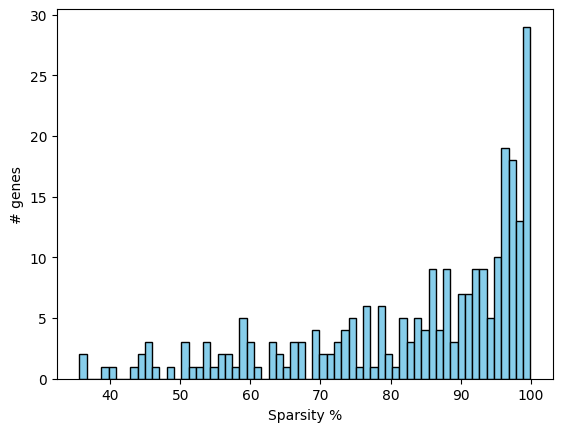

In [14]:
plt.hist(sparsity_sc*100, bins=62, color='skyblue', edgecolor='black')
plt.xlabel('Sparsity %')
plt.ylabel('# genes')
plt.show()

From the histogram of sparsity level across genes we can define a proper threshold:

In [184]:
sparsity_threshold = 0.90
mask_sc = (sparsity_sc > sparsity_threshold)
mask_sc.sum()

np.int64(125)

In [27]:
# Compute fraction of 0 expression cells for each gene
train_gene_indices_st = [adata_st_153.var_names.get_loc(g) for g in adata_st_153.uns['training_genes']]
sparsity_st = (adata_st_153.X[:, train_gene_indices_st] == 0).sum(axis=0)/adata_st_153.X.shape[0]

In [54]:
# Make pandas series with gene names as index
sparsity_st_series = pd.Series(data=sparsity_st, index=adata_st_153.var_names[train_gene_indices_st])

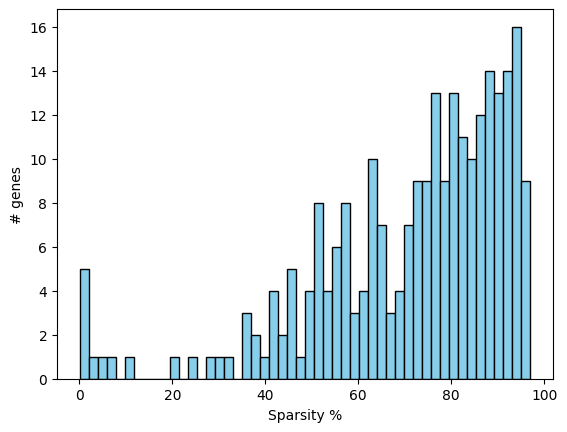

In [16]:
plt.hist(sparsity_st*100, bins=50, color='skyblue', edgecolor='black')
plt.xlabel('Sparsity %')
plt.ylabel('# genes')
plt.show()

For spatial data the situation is slighly better:

In [48]:
mask_st = (sparsity_st > sparsity_threshold)
mask_st.sum()

NameError: name 'sparsity_threshold' is not defined

With the following lines, we can quickly appreciate the entity of the intersection by means of a traffic-light plot:

*NOTE*: the sparsity signal is continuous and determines the color intensity/brightness.

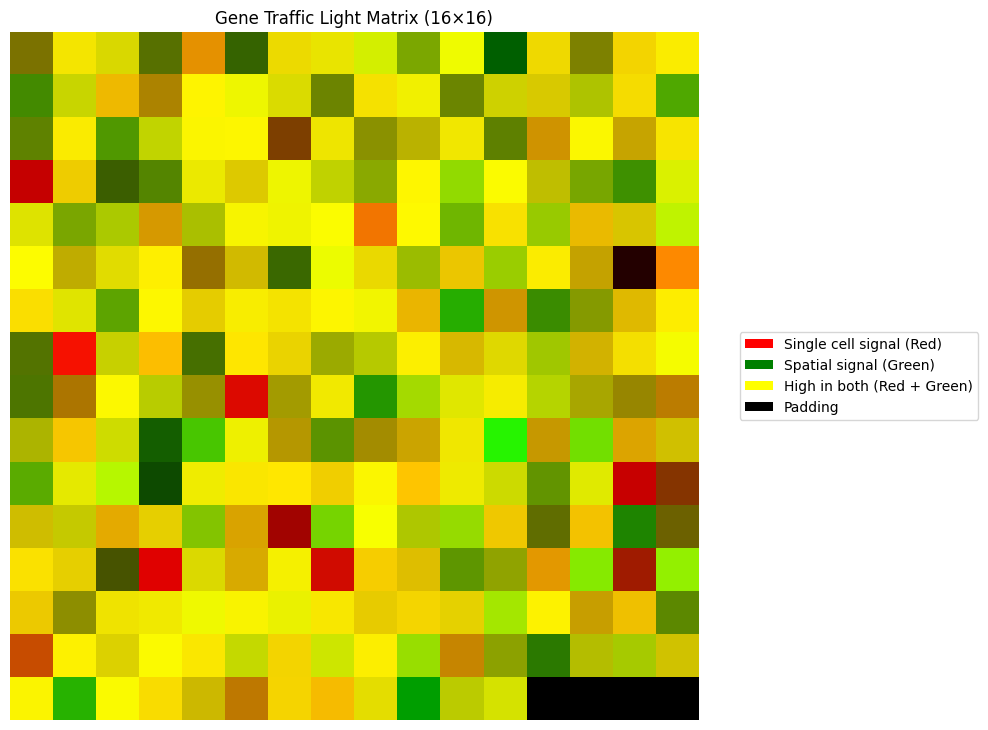

In [59]:
tg.traffic_light_plot(adata_sc.uns['training_genes'], sparsity_sc_series, sparsity_st_series)

### Expression levels
Here, instead, we try to gain some biological insight into the training genes set by observing whether or not they exhibit either high variability in the single cell data or strong spatial correlation:

In [191]:
adata_sc.var

,gene_ids,feature_types,highly_variable,highly_variable_rank,means,variances,variances_norm,n_cells
xkr4,0,Gene Expression,False,NaN,2.405056,2.982341,1.251456,70569
gm1992,1,Gene Expression,False,NaN,0.485666,0.542413,0.966567,37401
gm37381,2,Gene Expression,False,NaN,0.003646,0.003860,0.847213,443
rp1,3,Gene Expression,False,NaN,0.022113,0.025509,0.863815,2488
sox17,4,Gene Expression,True,451.0,0.023107,0.057735,1.868476,1053
...,...,...,...,...,...,...,...,...
ac168977.1,31048,Gene Expression,False,NaN,0.000815,0.000999,1.012864,84
ac149090.1,31049,Gene Expression,False,NaN,1.871865,1.652784,0.881002,74071
caaa01118383.1,31050,Gene Expression,False,NaN,0.134559,0.183607,1.053810,12034
vmn2r122,31051,Gene Expression,False,NaN,0.000008,0.000006,1.000021,1


In [35]:
# Create sc mask
# Set mask = 1 for HVGs
mask_sc = adata_sc.var.loc[adata_sc.uns['training_genes'], 'highly_variable']  # on training genes only
print(f"Number of HVGs={mask_sc.sum()} over number of training genes={mask_sc.shape[0]}")

Number of HVGs=100 over number of training genes=252


In [47]:
mask_sc.index  # already contains gene names

Index(['cnr1', 'cplx3', 'vwc2', 'camk2d', 'sertm1', 'shisa9', 'nr2f2', 'rerg',
       'l3mbtl4', 'olfm3',
       ...
       'hpse', 'lsp1', 'fezf2', 'gad1', 'cldn5', 'calb2', 'col23a1', 'rfx3',
       'tmem163', 'opalin'],
      dtype='object', length=252)

For spatial data correlation we just use the continuous moran I statisc:

In [44]:
adata_st_153.var_names

Index(['1700022i11rik', '1810046k07rik', '5031425f14rik', '5730522e02rik',
       'acta2', 'adam2', 'adamts2', 'adamts4', 'adra1b', 'alk',
       ...
       'gad2', 'tac2', 'lamp5', 'cnr1', 'pvalb', 'sst', 'rab3b', 'slc17a7',
       'penk', 'gad1'],
      dtype='object', length=254)

In [42]:
adata_st_153.uns['moranI']

,I,pval_norm,var_norm,pval_norm_fdr_bh
Rorb,0.507490,0.000000,0.000041,0.000000
Cux2,0.487229,0.000000,0.000041,0.000000
Lamp5,0.455303,0.000000,0.000041,0.000000
Calb1,0.440135,0.000000,0.000041,0.000000
Bcl11b,0.431898,0.000000,0.000041,0.000000
...,...,...,...,...
5031425F14Rik,-0.002627,0.349396,0.000041,0.360759
Cdcp1,-0.004777,0.235531,0.000041,0.244183
1700022I11Rik,-0.004966,0.226613,0.000041,0.236872
5730522E02Rik,-0.005272,0.212558,0.000041,0.224957


In [77]:
# Use lambda function to convert gene names to lower case
adata_st_153.uns['moranI'].index = adata_st_153.uns['moranI'].index.map(lambda x: str(x).lower())
adata_st_153.uns['moranI']

,I,pval_norm,var_norm,pval_norm_fdr_bh
rorb,0.507490,0.000000,0.000041,0.000000
cux2,0.487229,0.000000,0.000041,0.000000
lamp5,0.455303,0.000000,0.000041,0.000000
calb1,0.440135,0.000000,0.000041,0.000000
bcl11b,0.431898,0.000000,0.000041,0.000000
...,...,...,...,...
5031425f14rik,-0.002627,0.349396,0.000041,0.360759
cdcp1,-0.004777,0.235531,0.000041,0.244183
1700022i11rik,-0.004966,0.226613,0.000041,0.236872
5730522e02rik,-0.005272,0.212558,0.000041,0.224957


In [78]:
# Create st mask
mask_st = adata_st_153.uns['moranI'].loc[adata_st_153.uns['training_genes'],'I']
mask_st.shape[0]

252

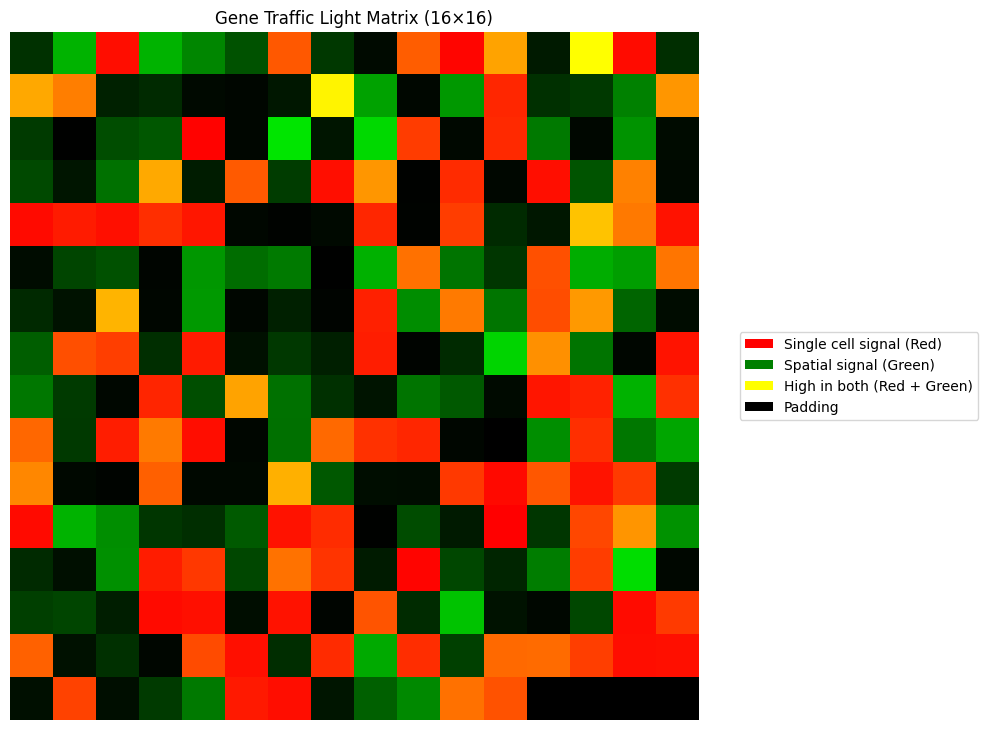

In [79]:
tg.traffic_light_plot(adata_sc.uns['training_genes'], mask_sc, mask_st)

Fully red boxes are scrna HVGs, while yellow boxes are also spatially correlated (remind that this plot does not resemble any spatial structure) and green boxes are only correlated spatially and are not HVGs

Black spots refer to non HVGs that also exhibit low spatial correlation. We can check that numerous spots have a low morans' statistic.

In [89]:
sum(adata_st_153.uns['moranI']['I']<0.01)

33

# Crop SC data
We decide to save a new anndata file for the single cell data reducing the columns/variables to only the set of genes intersecting with spatial data:

In [71]:
adata_sc_crop = adata_sc[:,overlap_genes].copy()
adata_sc_crop

AnnData object with n_obs × n_vars = 100000 × 252
    obs: 'nUMI', 'nGene', 'dataset', 'QC', 'cluster', 'Allen.cluster_id', 'Allen.cluster_label', 'Allen.cluster_color', 'Allen.class_label', 'Allen.subclass_label', 'comb.QC'
    var: 'gene_ids', 'feature_types', 'n_cells'
    uns: 'training_genes', 'overlap_genes'

In [82]:
adata_sc_crop.write_h5ad(filename='H:/Il mio Drive/data_tangram/counts100k_norm_wo_raw_train_genes.h5ad')

# Cross validation
TODO: Section to cross validate training gene set.